<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [2]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [3]:
# Your code here
import requests
from bs4 import BeautifulSoup
import csv

Download the webpage at the url


In [4]:
#your code goes here
response = requests.get(url)
data = response.text

Create a soup object


In [5]:
#your code goes here
soup = BeautifulSoup(data, "html.parser")

Scrape the `Language name` and `annual average salary`.


In [6]:
# Initialize an empty list to store the extracted data
popular_languages = []

# Locate the table element within the HTML
table = soup.find('table') 

# Iterate through each table row (<tr> tag)
for row in table.find_all('tr'): 
    # Find all table data cells (<td> tags) within the current row
    cols = row.find_all('td') 
    
    # Check if the row contains columns to avoid errors (e.g., empty rows)
    if len(cols) > 0:
        # Extract the language name from the 2nd column (index 1)
        # and the salary from the 4th column (index 3)
        language_name = cols[1].getText()
        annual_average_salary = cols[3].getText()
        
        # Store the extracted pair into our result list
        popular_languages.append([language_name, annual_average_salary])

# Optional: Preview the list
print(popular_languages)

[['Language', 'Average Annual Salary'], ['Python', '$114,383'], ['Java', '$101,013'], ['R', '$92,037'], ['Javascript', '$110,981'], ['Swift', '$130,801'], ['C++', '$113,865'], ['C#', '$88,726'], ['PHP', '$84,727'], ['SQL', '$84,793'], ['Go', '$94,082']]


Save the scrapped data into a file named *popular-languages.csv*


In [6]:
# your code goes here
# 5. Save into CSV file
with open("popular-languages.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(popular_languages)

print("保存完了: popular-languages.csv が作成されました。")

保存完了: popular-languages.csv が作成されました。


/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/ipykernel_launcher.py:9: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  if __name__ == "__main__":


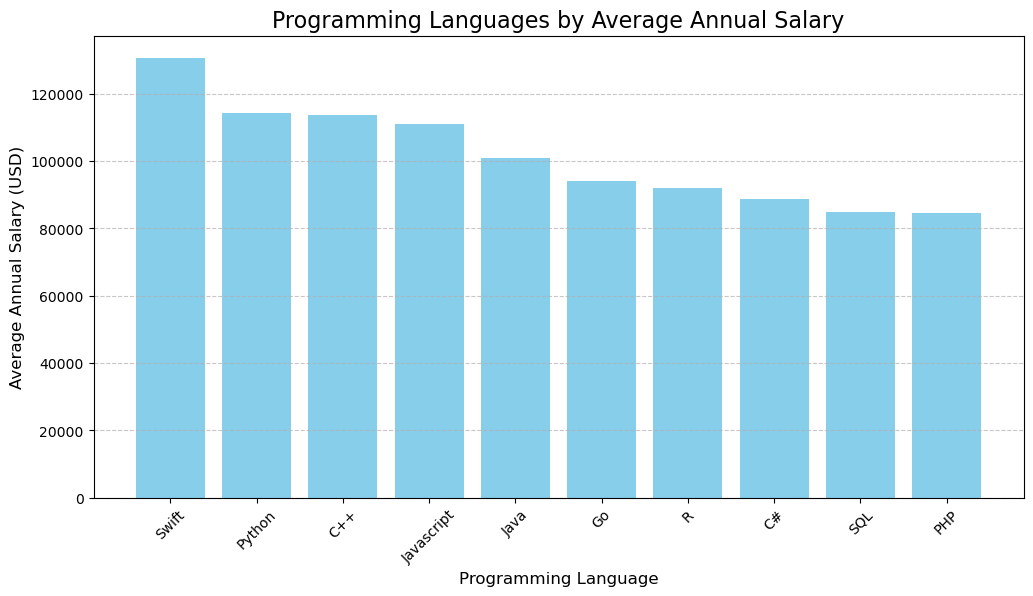

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. データの読み込み
df = pd.read_csv("popular-languages.csv")

# 2. データクリーニング（重要！）
# 年収データが "$123,456" のような文字列なので、計算可能な数値に変換します
df['Average Annual Salary'] = df['Average Annual Salary'].str.replace('$', '').str.replace(',', '').astype(float)

# 3. 給与が高い順に並べ替え
df_sorted = df.sort_values(by='Average Annual Salary', ascending=False)

# 4. 棒グラフで可視化
plt.figure(figsize=(12, 6))
plt.bar(df_sorted['Language'], df_sorted['Average Annual Salary'], color='skyblue')

# グラフの装飾
plt.title('Programming Languages by Average Annual Salary', fontsize=16)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Average Annual Salary (USD)', fontsize=12)
plt.xticks(rotation=45) # 言語名が重ならないように斜めにする
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
